In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from scipy.stats import zscore

In [2]:
file_paths = ['0000.parquet', '0001.parquet', '0002.parquet', '0003.parquet', '0004.parquet', '0005.parquet']
dfs = [pd.read_parquet(file) for file in file_paths if os.path.exists(file)]  # Check if files exist
full_data = pd.concat(dfs, ignore_index=True)  # Merge into a single DataFrame


In [3]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB


In [4]:
full_data.describe()

,videoid
count,1.072761e+07
mean,5.798212e+08
std,5.044656e+08
min,1.300000e+01
25%,1.906638e+07
50%,1.010962e+09
75%,1.032311e+09
max,1.067376e+09


In [5]:
full_data.head()

,videoid,contentUrl,duration,page_dir,name
0,21179416,https://ak.picdn.net/shutterstock/videos/21179...,PT00H00M11S,006001_006050,Aerial shot winter forest
1,5629184,https://ak.picdn.net/shutterstock/videos/56291...,PT00H00M29S,071501_071550,Senior couple looking through binoculars on sa...
2,1063125190,https://ak.picdn.net/shutterstock/videos/10631...,PT00H00M07S,133701_133750,A beautiful cookie with oranges lies on a gree...
3,1039695998,https://ak.picdn.net/shutterstock/videos/10396...,PT00H00M08S,011901_011950,Japanese highrise office skyscrapers tokyo square
4,9607838,https://ak.picdn.net/shutterstock/videos/96078...,PT00H00M32S,121551_121600,"Zrenjanin,serbia march 21 2015: fans watching ..."


In [6]:
def convert_duration(duration):
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration)
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    return hours * 3600 + minutes * 60 + seconds

In [31]:
full_data['duration_sec'] = full_data['duration'].apply(lambda x: convert_duration(x) if pd.notnull(x) else 0)


In [32]:
print("Is videoid unique?", full_data['videoid'].is_unique)
print("Duplicate Video Counts:\n", full_data['videoid'].value_counts().head(10))

Is videoid unique? False
Duplicate Video Counts:
 videoid
1066696999    2
1066697260    2
1066676881    2
1065521032    2
1059155453    2
1059150260    2
1062722287    2
1058060785    2
1027554365    2
1065867481    2
Name: count, dtype: int64


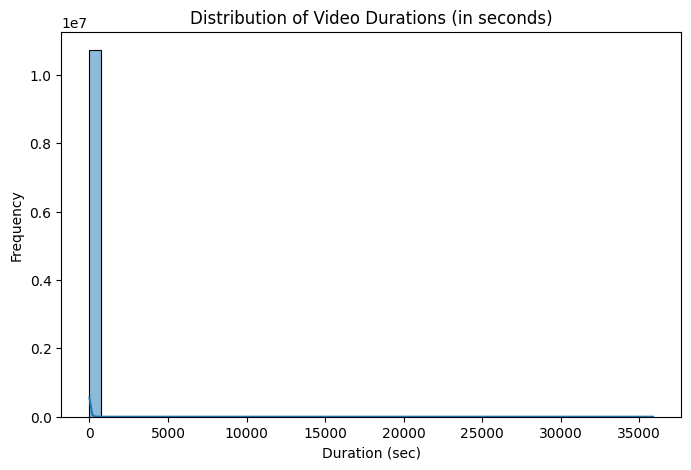

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(full_data['duration_sec'], bins=50, kde=True)
plt.title('Distribution of Video Durations (in seconds)')
plt.xlabel('Duration (sec)')
plt.ylabel('Frequency')
plt.show()

In [45]:
movie_data=full_data

In [47]:

movie_data['duration_sec'] = pd.to_numeric(movie_data['duration_sec'], errors='coerce')

# 1. Identify short videos (0 seconds)
short_videos = movie_data[movie_data['duration_sec'] == 0]

# 2. Identify long videos (> 5 minutes or 300 seconds)
long_videos = movie_data[movie_data['duration_sec'] > 300]

# 3. Print the count of short and long videos
print(f"Number of 0-second videos: {len(short_videos)}")
print(f"Number of long videos (>5 min): {len(long_videos)}")

# 4. Filter out the 0-second and long videos (> 5 min), keeping videos within the 0-5 min range
movie_data = movie_data[(movie_data['duration_sec'] > 0) & (movie_data['duration_sec'] <= 300)]

# Optionally, check the new dataset
print(movie_data.head())



Number of 0-second videos: 270
Number of long videos (>5 min): 271
      videoid                                         contentUrl     duration  \
0    21179416  https://ak.picdn.net/shutterstock/videos/21179...  PT00H00M11S   
1     5629184  https://ak.picdn.net/shutterstock/videos/56291...  PT00H00M29S   
2  1063125190  https://ak.picdn.net/shutterstock/videos/10631...  PT00H00M07S   
3  1039695998  https://ak.picdn.net/shutterstock/videos/10396...  PT00H00M08S   
4     9607838  https://ak.picdn.net/shutterstock/videos/96078...  PT00H00M32S   

        page_dir                                               name  \
0  006001_006050                          Aerial shot winter forest   
1  071501_071550  Senior couple looking through binoculars on sa...   
2  133701_133750  A beautiful cookie with oranges lies on a gree...   
3  011901_011950  Japanese highrise office skyscrapers tokyo square   
4  121551_121600  Zrenjanin,serbia march 21 2015: fans watching ...   

   duration_sec  
0

VIDEO DURATION BY PAGE DIRECTORY

C:\Users\acer\AppData\Local\Temp\ipykernel_23792\4010127419.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movie_data.head(10), x='page_dir', y='duration_sec', palette='Set2')


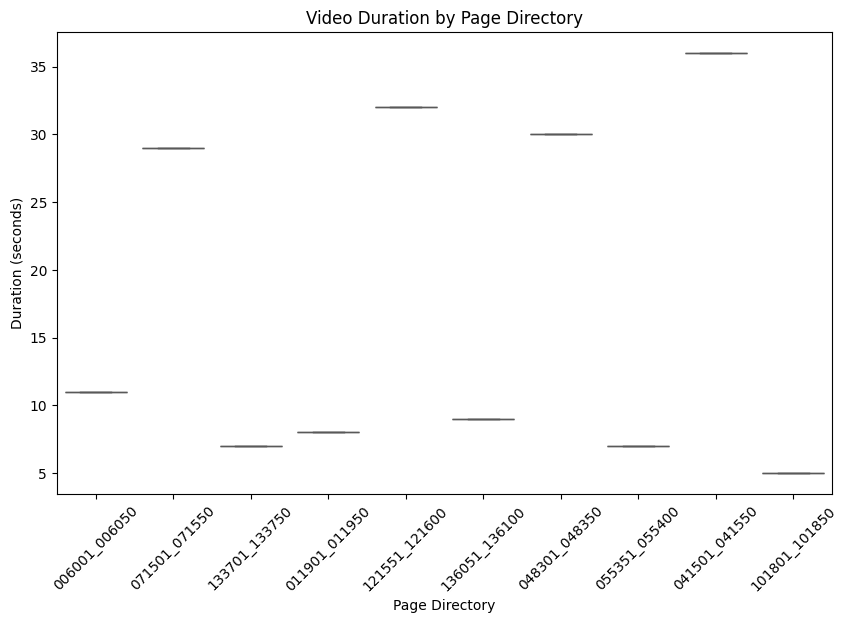

In [49]:
plt.figure(figsize=(10,6))
sns.boxplot(data=movie_data.head(10), x='page_dir', y='duration_sec', palette='Set2')
plt.title('Video Duration by Page Directory')
plt.xlabel('Page Directory')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.show()


page_dir
099101_099150    19.140919
040401_040450    18.785806
185601_185650    18.774830
129301_129350    18.773705
094751_094800    18.729557
048501_048550    18.705961
082301_082350    18.704847
094951_095000    18.690372
105551_105600    18.682993
017901_017950    18.654834
Name: duration_sec, dtype: float64


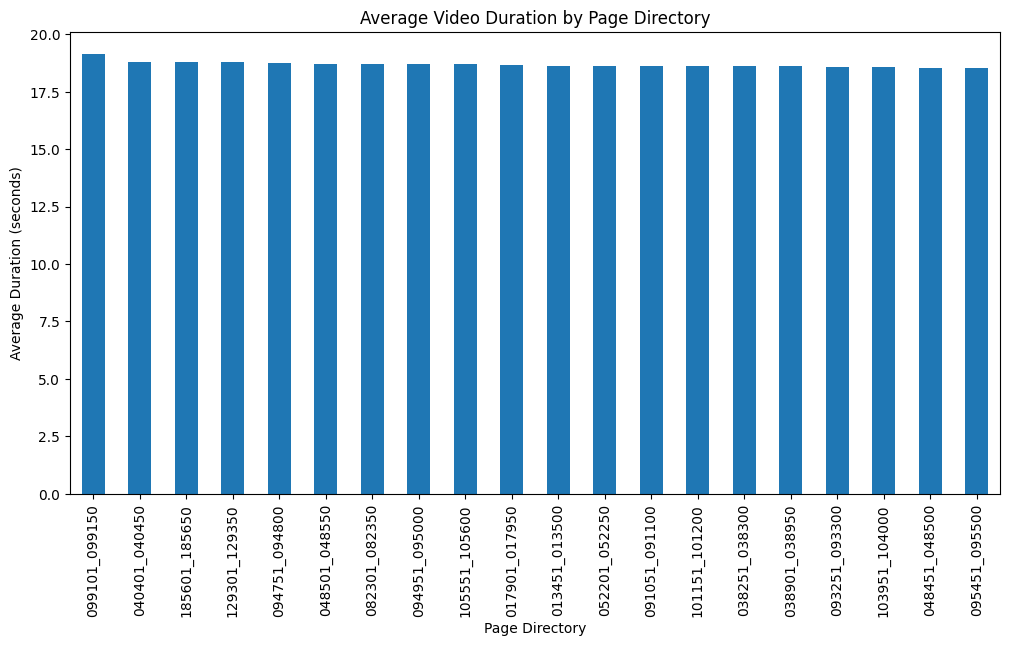

In [51]:
duration_by_category = movie_data.groupby('page_dir')['duration_sec'].mean().sort_values(ascending=False)
print(duration_by_category.head(10))
 
# Bar plot of average duration per category
duration_by_category.head(20).plot(kind='bar', figsize=(12, 6), title='Average Video Duration by Page Directory')
plt.xlabel("Page Directory")
plt.ylabel("Average Duration (seconds)")
plt.show()

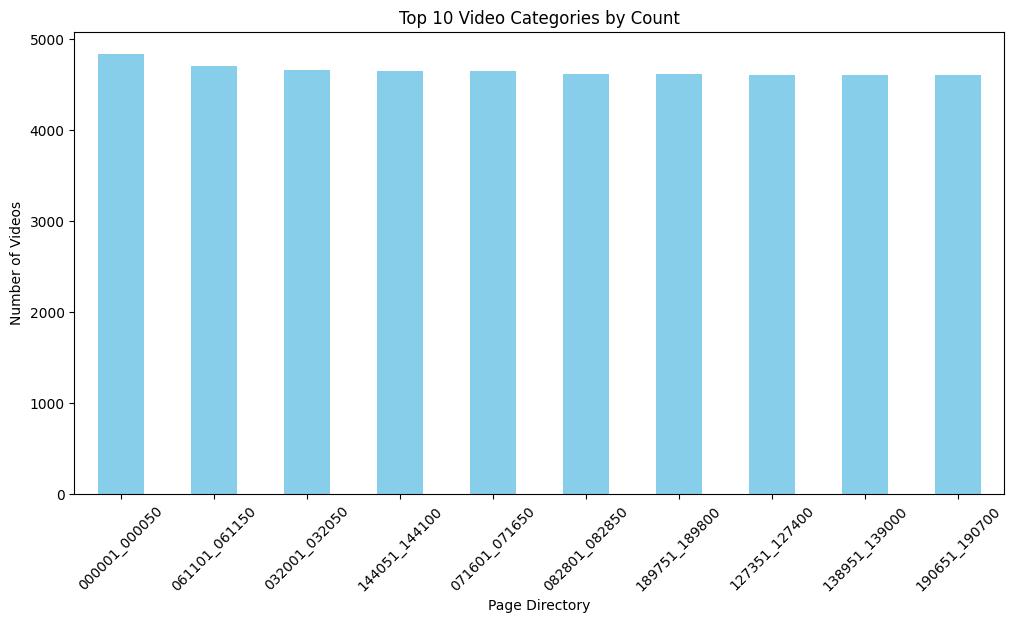

In [52]:
top_categories_count = movie_data['page_dir'].value_counts().head(10)

# Plot the top 10 video categories by count
plt.figure(figsize=(12, 6))
top_categories_count.plot(kind='bar', color='skyblue')
plt.title('Top 10 Video Categories by Count')
plt.xlabel('Page Directory')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.show()

VIDEO EXTRACTION

In [54]:
import os
import requests

# Create a directory for saving the videos
save_folder = "downloaded_videos"
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

# Assuming `movie_data` DataFrame contains the 'contentUrl' column with video URLs
video_urls = movie_data['contentUrl'].dropna()  # Drop any NaN URLs

# Limit to first 20 videos
video_urls = video_urls.head(20)

# Function to download videos and save them in the specified folder
def download_video(url, save_folder):
    try:
        video_data = requests.get(url)
        video_name = url.split('/')[-1]  # Extract video name from URL
        save_path = os.path.join(save_folder, video_name)  # Full path for saving the video
        
        # Save the video content to the file
        with open(save_path, 'wb') as file:
            file.write(video_data.content)
        print(f"Video saved: {save_path}")
    except Exception as e:
        print(f"Failed to download {url}: {str(e)}")

# Download the first 20 videos and save to the folder
for url in video_urls:
    download_video(url, save_folder)

print("20 videos have been downloaded and saved.")



Video saved: downloaded_videos\stock-footage-aerial-shot-winter-forest.mp4
Video saved: downloaded_videos\stock-footage-senior-couple-looking-through-binoculars-on-sailboat-together-shot-on-red-epic-for-high-quality-k.mp4
Video saved: downloaded_videos\stock-footage-a-beautiful-cookie-with-oranges-lies-on-a-green-tablecloth.mp4
Video saved: downloaded_videos\stock-footage-japanese-highrise-office-skyscrapers-tokyo-square.mp4
Video saved: downloaded_videos\stock-footage-zrenjanin-serbia-march-fans-watching-live-concert-bokeh-blur-urban-background-x.mp4
Video saved: downloaded_videos\stock-footage-young-beautiful-woman-using-smartphone-in-cafe.mp4
Video saved: downloaded_videos\stock-footage--d-render-of-inky-injections-into-water-with-luma-matte-blue-ink-on-white-background.mp4
Video saved: downloaded_videos\stock-footage-swimming-in-the-pool-slow-motion-fps-handheld-camera-balanced-steady-shot.mp4
Video saved: downloaded_videos\stock-footage-circa-s-usa-woman-posing-for-camera-next-to-